# ATP and PRC Data Comparison
This notebook contains cross-dataset comparisons for ATP conditions and PRC conditions, plus a one-frame fluorescence autocorrelation radial-profile check (channel 0).

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import tomsUtilities
importlib.reload(tomsUtilities)
from tomsUtilities import (
    vector_correlation_3d,
    spatial_vector_correlation_per_frame,
    read_zarr_calibration,
    open_raw_lazy,
    _fit_exp_decay_positive_x,
)

plt.style.use('./science.mplstyle.txt')
plt.style.use('dark_background')

base_dir = "/Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260225"
datasets_cmp = [
    ("AMF_088_002__C640_C470", "2 mM ATP", "#08306b"),
    ("AMF_101_002__C640_C470", "0.6 mM ATP", "#08519c"),
    ("AMF_089_003__C640_C470", "0.2 mM ATP", "#2171b5"),
    ("AMF_090_003__C640_C470", "0.02 mM ATP", "#6baed6"),
]

out_dir = "plots/data_comparison"
os.makedirs(out_dir, exist_ok=True)

Saved: plots/data_comparison/ATP_comparison_temporal.pdf


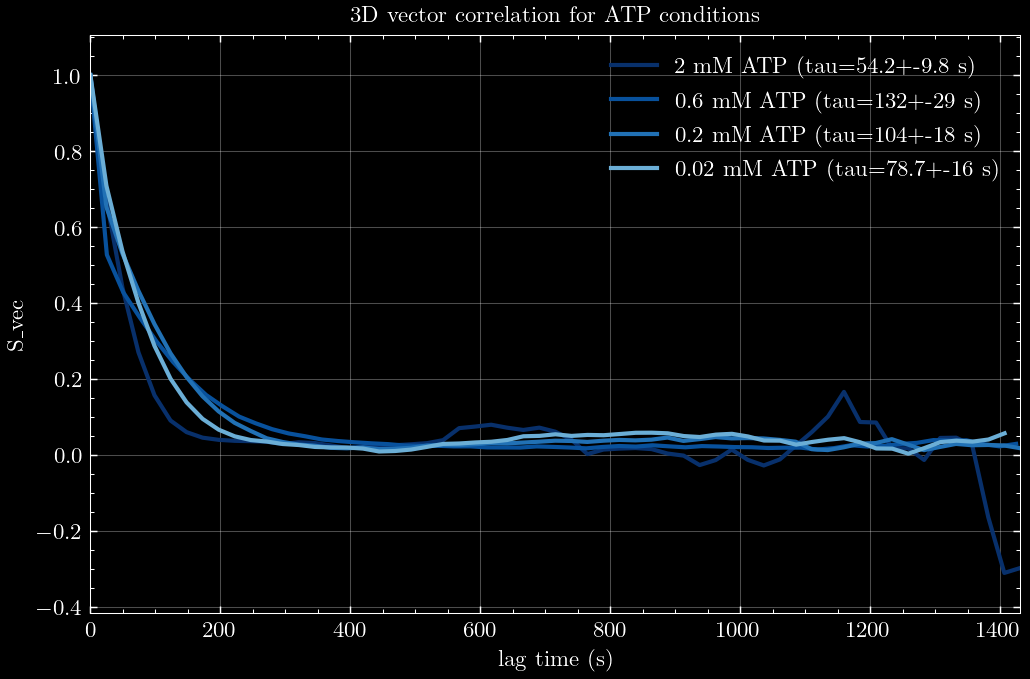

Saved: plots/data_comparison/ATP_comparison_spatial.pdf


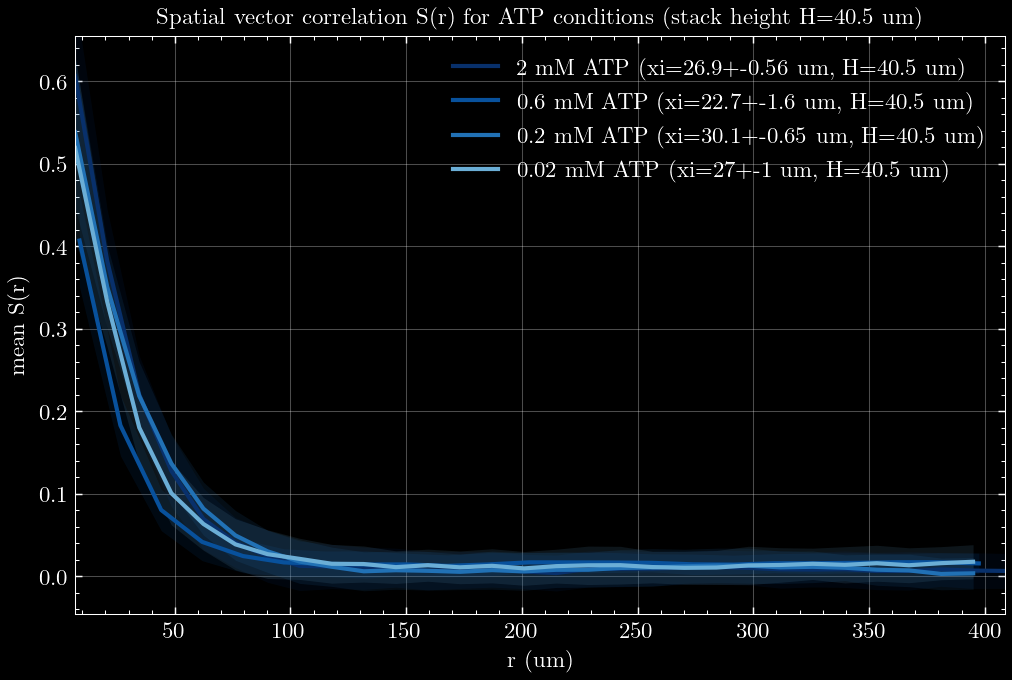

In [8]:
# Temporal + spatial vector-correlation comparisons
temporal_curves = []
spatial_curves = []
velocity_curves = []

for ds_id, ds_label, ds_color in datasets_cmp:
    vel_candidates = [
        f"data/{ds_id}/derived/beads_tracks_with_velocity.parquet",
        os.path.join(base_dir, ds_id, "derived", "beads_tracks_with_velocity.parquet"),
        os.path.join("/Volumes/TOM_DATA", ds_id, "derived", "beads_tracks_with_velocity.parquet"),
    ]
    vel_path = next((p for p in vel_candidates if os.path.exists(p)), None)
    if vel_path is None:
        print(f"Skipping {ds_id}: no velocity parquet found")
        continue

    df_ds = pd.read_parquet(vel_path)
    if len(df_ds) == 0:
        print(f"Skipping {ds_id}: empty velocity parquet")
        continue

    try:
        _, px_per_micron_ds, px_per_micron_z_ds, fps_ds = read_zarr_calibration(ds_id, base_dir=base_dir)
    except Exception:
        try:
            _, px_per_micron_ds, px_per_micron_z_ds, fps_ds = read_zarr_calibration(ds_id, base_dir="/Volumes/TOM_DATA")
        except Exception:
            px_per_micron_ds, px_per_micron_z_ds, fps_ds = None, None, None

    stack_height_um = np.nan
    try:
        images_ds, _ = open_raw_lazy(ds_id, base_dir=base_dir)
    except Exception:
        try:
            images_ds, _ = open_raw_lazy(ds_id, base_dir="/Volumes/TOM_DATA")
        except Exception:
            images_ds = None

    if images_ds is not None:
        z_size_px = float(images_ds.shape[2])
        if px_per_micron_z_ds is not None and float(px_per_micron_z_ds) > 0:
            stack_height_um = z_size_px / float(px_per_micron_z_ds)

    max_lag_ds = int(df_ds['frame'].max() - df_ds['frame'].min())
    corr_ds = vector_correlation_3d(
        df_ds,
        max_lag=max_lag_ds,
        fps=(float(fps_ds) if fps_ds is not None else None),
        min_pairs=5,
        normalize=False,
    )
    x_t = corr_ds['tau_s'].to_numpy(dtype=float)
    y_t = corr_ds['S_vec'].to_numpy(dtype=float)
    fit_t = _fit_exp_decay_positive_x(x_t, y_t, min_points=5)
    temporal_curves.append((ds_label, ds_color, x_t, y_t, fit_t))

    sp_df = spatial_vector_correlation_per_frame(
        df_ds,
        r_max_um=None,
        nbins=30,
        min_pairs=5,
    )
    pivot = sp_df.pivot(index='frame', columns='r_um', values='S_vec_spatial').sort_index()
    r = pivot.columns.to_numpy(dtype=float)
    arr = pivot.to_numpy(dtype=float)
    s_mean = np.nanmean(arr, axis=0)
    s_std = np.nanstd(arr, axis=0)
    fit_s = _fit_exp_decay_positive_x(r, s_mean, min_points=5)
    spatial_curves.append((ds_label, ds_color, r, s_mean, s_std, fit_s, stack_height_um))

    speed_stats = df_ds.groupby('frame', sort=True)['speed_um_s'].agg(['mean', 'std'])
    fr = speed_stats.index.to_numpy(dtype=float)
    t_s = fr / float(fps_ds) if (fps_ds is not None and float(fps_ds) > 0) else fr
    v_mean = speed_stats['mean'].to_numpy(dtype=float)
    v_std = speed_stats['std'].to_numpy(dtype=float)
    velocity_curves.append((ds_label, ds_color, t_s, v_mean, v_std))

if not temporal_curves or not spatial_curves:
    raise RuntimeError('Could not compute temporal/spatial comparison curves')

temporal_ranges = [float(np.nanmax(x[np.isfinite(x) & np.isfinite(y)])) for _, _, x, y, _ in temporal_curves if np.any(np.isfinite(x) & np.isfinite(y))]
if not temporal_ranges:
    raise RuntimeError('Temporal: no finite points to plot')
xmax_common_t = float(np.nanmin(temporal_ranges))

fig_t, ax_t = plt.subplots(figsize=(8, 5), dpi=150)
y_pool_t = []
for ds_label, ds_color, x, y, fit_t in temporal_curves:
    v = np.isfinite(x) & np.isfinite(y) & (x <= xmax_common_t)
    if not np.any(v):
        continue
    xv = x[v]
    yv = y[v]
    y_pool_t.append(yv)

    if fit_t.get('success', False):
        tau = float(fit_t['tau'])
        tau_se = float(fit_t.get('tau_se', np.nan))
        lbl = f"{ds_label} (tau={tau:.3g}+-{tau_se:.2g} s)" if np.isfinite(tau_se) else f"{ds_label} (tau={tau:.3g} s)"
    else:
        lbl = f"{ds_label} (fit n/a)"
    ax_t.plot(xv, yv, lw=2.0, color=ds_color, label=lbl)

ax_t.set_xlabel('lag time (s)')
ax_t.set_ylabel('S_vec')
ax_t.set_title('3D vector correlation for ATP conditions')
ax_t.set_xlim(0, xmax_common_t)
if y_pool_t:
    y_all = np.concatenate(y_pool_t)
    ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
    ax_t.set_ylim(ylo - pad, yhi + pad)
ax_t.grid(True, alpha=0.3)
ax_t.legend(loc='best', frameon=False)
pdf_cmp_t = os.path.join(out_dir, 'ATP_comparison_temporal.pdf')
fig_t.savefig(pdf_cmp_t, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_cmp_t}')
plt.show()

spatial_ranges = [float(np.nanmax(r[np.isfinite(r) & np.isfinite(s_mean)])) for _, _, r, s_mean, _, _, _ in spatial_curves if np.any(np.isfinite(r) & np.isfinite(s_mean))]
if not spatial_ranges:
    raise RuntimeError('Spatial: no finite points to plot')
xmax_common_s = float(np.nanmin(spatial_ranges))

fig_s, ax_s = plt.subplots(figsize=(8, 5), dpi=150)
y_pool_s = []
xmin_pool_s = []
stack_heights = []
for ds_label, ds_color, r, s_mean, s_std, fit_s, stack_height_um in spatial_curves:
    v = np.isfinite(r) & np.isfinite(s_mean) & (r <= xmax_common_s)
    if not np.any(v):
        continue
    rv = r[v]
    mv = s_mean[v]
    sv = s_std[v] if s_std is not None else np.full_like(mv, np.nan)
    y_pool_s.append(mv)
    xmin_pool_s.append(float(np.nanmin(rv)))
    if np.isfinite(stack_height_um):
        stack_heights.append(float(stack_height_um))

    if fit_s.get('success', False):
        xi = float(fit_s['tau'])
        xi_se = float(fit_s.get('tau_se', np.nan))
        fit_txt = f"xi={xi:.3g}+-{xi_se:.2g} um" if np.isfinite(xi_se) else f"xi={xi:.3g} um"
    else:
        fit_txt = 'fit n/a'

    h_txt = f"H={stack_height_um:.3g} um" if np.isfinite(stack_height_um) else 'H=n/a'
    lbl = f"{ds_label} ({fit_txt}, {h_txt})"
    ax_s.plot(rv, mv, lw=2.0, color=ds_color, label=lbl)
    std_ok = np.isfinite(sv)
    if np.any(std_ok):
        ax_s.fill_between(rv[std_ok], (mv - sv)[std_ok], (mv + sv)[std_ok], color=ds_color, alpha=0.12, linewidth=0)

ax_s.set_xlabel('r (um)')
ax_s.set_ylabel('mean S(r)')
if stack_heights:
    hmin, hmax = float(np.nanmin(stack_heights)), float(np.nanmax(stack_heights))
    if np.isclose(hmin, hmax):
        ax_s.set_title(f'Spatial vector correlation S(r) for ATP conditions (stack height H={hmin:.3g} um)')
    else:
        ax_s.set_title(f'Spatial vector correlation S(r) for ATP conditions (stack heights H={hmin:.3g}-{hmax:.3g} um)')
else:
    ax_s.set_title('Spatial vector correlation S(r) for ATP conditions (stack height unavailable)')
ax_s.set_xlim(float(np.nanmin(xmin_pool_s)) if xmin_pool_s else 0.0, xmax_common_s)
if y_pool_s:
    y_all = np.concatenate(y_pool_s)
    ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
    ax_s.set_ylim(ylo - pad, yhi + pad)
ax_s.grid(True, alpha=0.3)
ax_s.legend(loc='best', frameon=False)
pdf_cmp_s = os.path.join(out_dir, 'ATP_comparison_spatial.pdf')
fig_s.savefig(pdf_cmp_s, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_cmp_s}')
plt.show()

Saved: plots/data_comparison/ATP_comparison_velocity.pdf


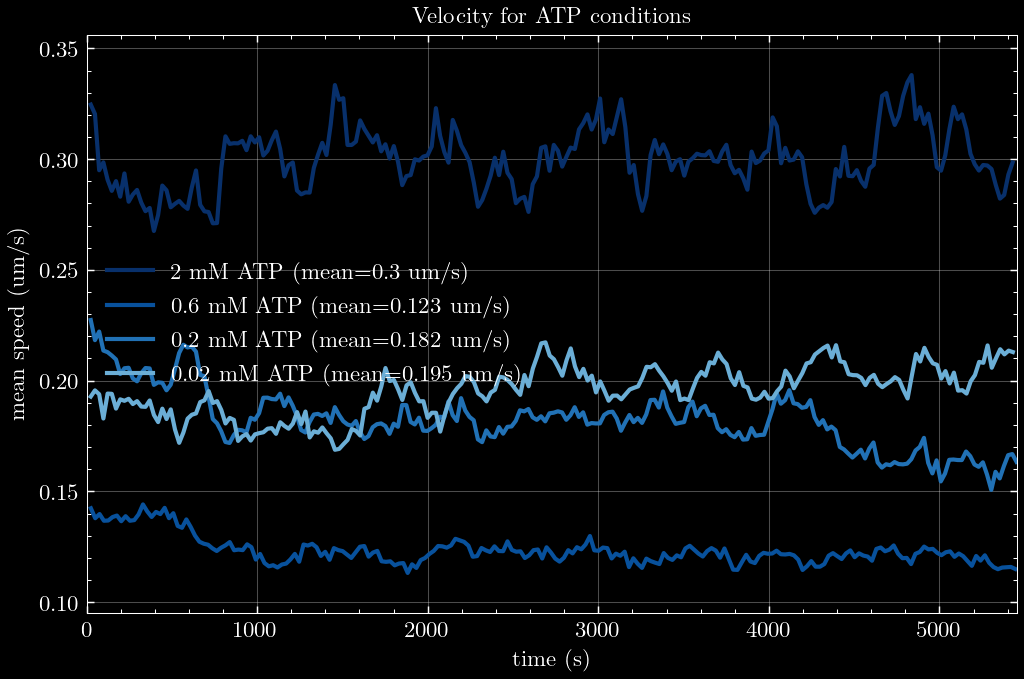

In [9]:
# Velocity comparison
if not velocity_curves:
    raise RuntimeError('No velocity curves were computed')

velocity_ranges = [float(np.nanmax(t_s[np.isfinite(t_s) & np.isfinite(v_mean)])) for _, _, t_s, v_mean, _ in velocity_curves if np.any(np.isfinite(t_s) & np.isfinite(v_mean))]
if not velocity_ranges:
    raise RuntimeError('Velocity: no finite points to plot')
xmax_common_v = float(np.nanmin(velocity_ranges))

fig_v, ax_v = plt.subplots(figsize=(8, 5), dpi=150)
y_pool_v = []
for ds_label, ds_color, t_s, v_mean, _ in velocity_curves:
    v = np.isfinite(t_s) & np.isfinite(v_mean) & (t_s <= xmax_common_v)
    if not np.any(v):
        continue
    tv = t_s[v]
    mv = v_mean[v]
    y_pool_v.append(mv)
    mean_speed = float(np.nanmean(mv))
    lbl = f"{ds_label} (mean={mean_speed:.3g} um/s)"
    ax_v.plot(tv, mv, lw=2.0, color=ds_color, label=lbl)

ax_v.set_xlabel('time (s)')
ax_v.set_ylabel('mean speed (um/s)')
ax_v.set_title('Velocity for ATP conditions')
ax_v.set_xlim(0, xmax_common_v)
if y_pool_v:
    y_all = np.concatenate(y_pool_v)
    ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
    ax_v.set_ylim(ylo - pad, yhi + pad)
ax_v.grid(True, alpha=0.3)
ax_v.legend(loc='best', frameon=False)
pdf_cmp_v = os.path.join(out_dir, 'ATP_comparison_velocity.pdf')
fig_v.savefig(pdf_cmp_v, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_cmp_v}')
plt.show()

## PRC Concentration Comparison
Compares PRC concentrations (0.1, 0.3, 0.6, 2.0 µM) using datasets stored in `/Volumes/TOM_DATA` with the same temporal/spatial/velocity analyses as ATP. For fluorescence autocorrelation, this section only plots radial profiles (no xi-vs-time figure).

In [5]:
# PRC computation: temporal + spatial vector-correlation + velocity (no plotting)
base_dir_prc = "/Volumes/TOM_DATA"
datasets_prc = [
    ("AMF_092_002__C640_C470", "0.1 µM PRC", "#a6dba0"),
    ("AMF_088_002__C640_C470", "0.3 µM PRC", "#5aae61"),
    ("AMF_091_002__C640_C470", "0.6 µM PRC", "#1b7837"),
    ("AMF_093_002__C640_C470", "2.0 µM PRC", "#00441b"),
]

out_dir_prc = os.path.join(out_dir, "prc_comparison")
os.makedirs(out_dir_prc, exist_ok=True)

prc_temporal_curves = []
prc_spatial_curves = []
prc_velocity_curves = []

for ds_id, ds_label, ds_color in datasets_prc:
    ds_id_resolved = ds_id

    vel_candidates = [
        f"data/{ds_id_resolved}/derived/beads_tracks_with_velocity.parquet",
        os.path.join(base_dir_prc, ds_id_resolved, "derived", "beads_tracks_with_velocity.parquet"),
        os.path.join(base_dir, ds_id_resolved, "derived", "beads_tracks_with_velocity.parquet"),
    ]
    vel_path = next((p for p in vel_candidates if os.path.exists(p)), None)
    if vel_path is None:
        print(f"Skipping {ds_id}: no velocity parquet found")
        continue

    df_ds = pd.read_parquet(vel_path)
    if len(df_ds) == 0:
        print(f"Skipping {ds_id}: empty velocity parquet")
        continue

    try:
        _, px_per_micron_ds, px_per_micron_z_ds, fps_ds = read_zarr_calibration(ds_id_resolved, base_dir=base_dir_prc)
    except Exception:
        px_per_micron_ds, px_per_micron_z_ds, fps_ds = None, None, None

    stack_height_um = np.nan
    try:
        images_ds, _ = open_raw_lazy(ds_id_resolved, base_dir=base_dir_prc)
        z_size_px = float(images_ds.shape[2])
        if px_per_micron_z_ds is not None and float(px_per_micron_z_ds) > 0:
            stack_height_um = z_size_px / float(px_per_micron_z_ds)
    except Exception:
        stack_height_um = np.nan

    max_lag_ds = int(df_ds['frame'].max() - df_ds['frame'].min())
    corr_ds = vector_correlation_3d(
        df_ds,
        max_lag=max_lag_ds,
        fps=(float(fps_ds) if fps_ds is not None else None),
        min_pairs=5,
        normalize=False,
    )
    x_t = corr_ds['tau_s'].to_numpy(dtype=float)
    y_t = corr_ds['S_vec'].to_numpy(dtype=float)
    fit_t = _fit_exp_decay_positive_x(x_t, y_t, min_points=5)
    prc_temporal_curves.append((ds_label, ds_color, x_t, y_t, fit_t))

    sp_df = spatial_vector_correlation_per_frame(
        df_ds,
        r_max_um=None,
        nbins=30,
        min_pairs=5,
    )
    pivot = sp_df.pivot(index='frame', columns='r_um', values='S_vec_spatial').sort_index()
    r = pivot.columns.to_numpy(dtype=float)
    arr = pivot.to_numpy(dtype=float)
    s_mean = np.nanmean(arr, axis=0)
    s_std = np.nanstd(arr, axis=0)
    fit_s = _fit_exp_decay_positive_x(r, s_mean, min_points=5)
    prc_spatial_curves.append((ds_label, ds_color, r, s_mean, s_std, fit_s, stack_height_um))

    speed_stats = df_ds.groupby('frame', sort=True)['speed_um_s'].agg(['mean', 'std'])
    fr = speed_stats.index.to_numpy(dtype=float)
    t_s = fr / float(fps_ds) if (fps_ds is not None and float(fps_ds) > 0) else fr
    v_mean = speed_stats['mean'].to_numpy(dtype=float)
    v_std = speed_stats['std'].to_numpy(dtype=float)
    prc_velocity_curves.append((ds_label, ds_color, t_s, v_mean, v_std))

if not prc_temporal_curves or not prc_spatial_curves:
    raise RuntimeError('Could not compute PRC temporal/spatial comparison curves')

prc_results = {
    'temporal_curves': prc_temporal_curves,
    'spatial_curves': prc_spatial_curves,
    'velocity_curves': prc_velocity_curves,
}

print(
    f"Computed PRC curves for {len(prc_temporal_curves)} datasets "
    f"(velocity: {len(prc_velocity_curves)}, spatial: {len(prc_spatial_curves)})."
)

Computed PRC curves for 4 datasets (velocity: 4, spatial: 4).


Saved: plots/data_comparison/prc_comparison/PRC_comparison_temporal.pdf


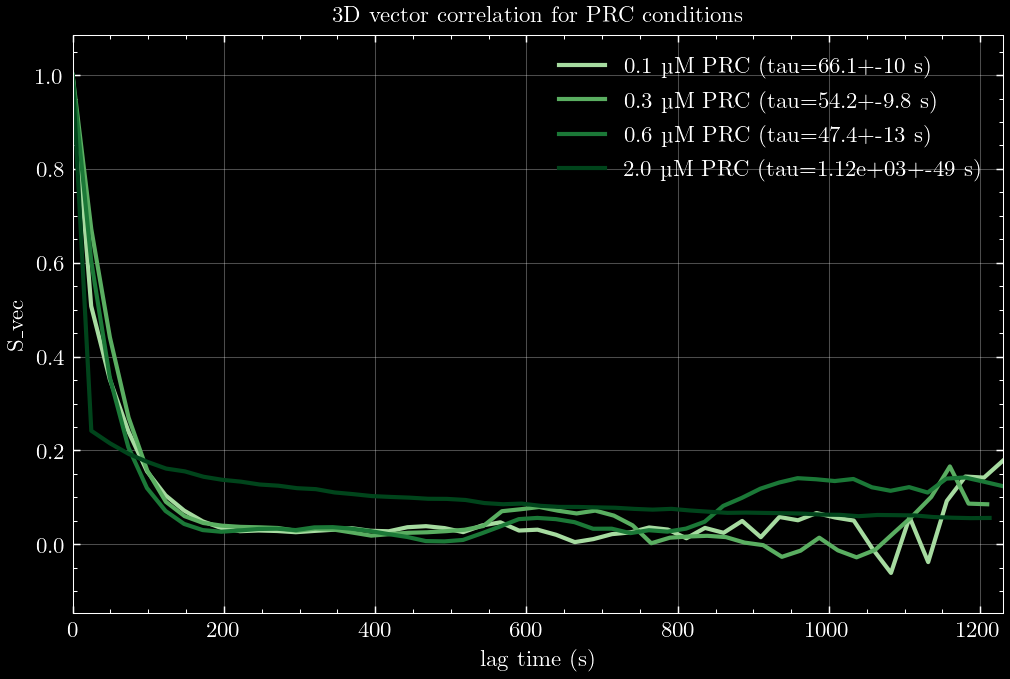

Saved: plots/data_comparison/prc_comparison/PRC_comparison_spatial.pdf


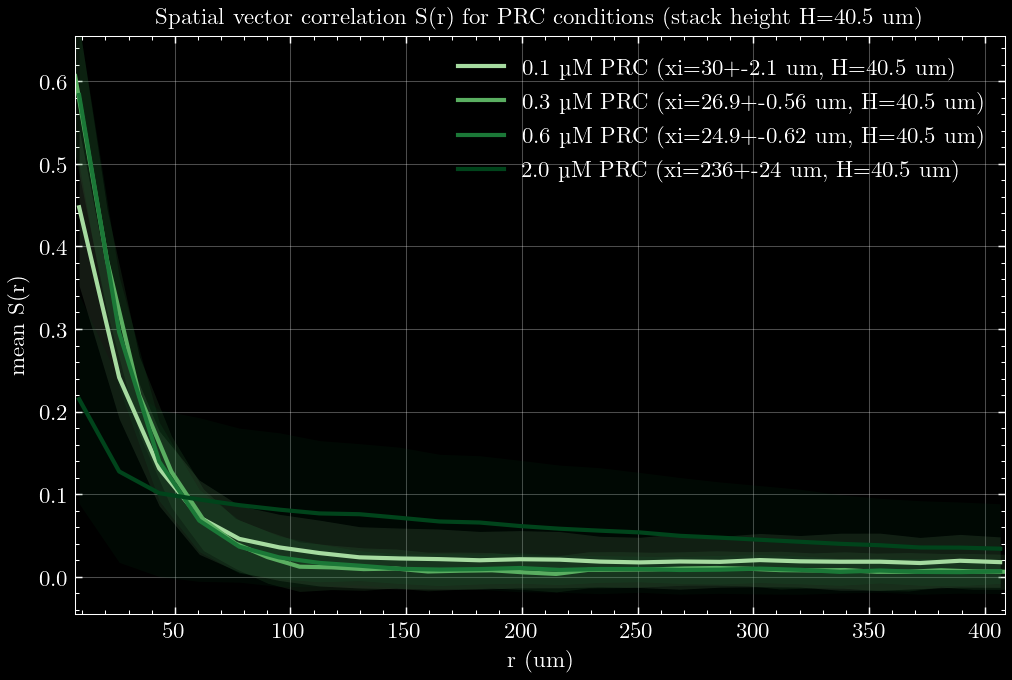

Saved: plots/data_comparison/prc_comparison/PRC_comparison_velocity.pdf


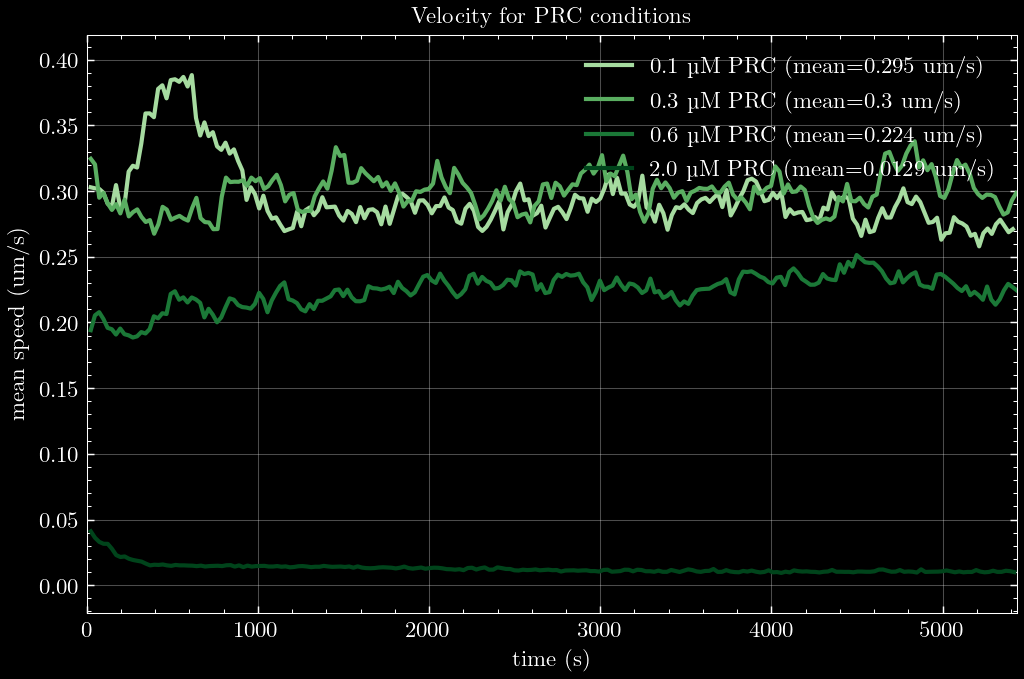

In [5]:
# PRC plotting: temporal + spatial + velocity (uses precomputed prc_results)
temporal_curves_prc = prc_results['temporal_curves']
spatial_curves_prc = prc_results['spatial_curves']
velocity_curves_prc = prc_results['velocity_curves']

# Temporal comparison
temporal_ranges = [
    float(np.nanmax(x[np.isfinite(x) & np.isfinite(y)]))
    for _, _, x, y, _ in temporal_curves_prc
    if np.any(np.isfinite(x) & np.isfinite(y))
]
if not temporal_ranges:
    raise RuntimeError('PRC temporal: no finite points to plot')
xmax_common_t = float(np.nanmin(temporal_ranges))

fig_t, ax_t = plt.subplots(figsize=(8, 5), dpi=150)
y_pool_t = []
for ds_label, ds_color, x, y, fit_t in temporal_curves_prc:
    v = np.isfinite(x) & np.isfinite(y) & (x <= xmax_common_t)
    if not np.any(v):
        continue
    xv = x[v]
    yv = y[v]
    y_pool_t.append(yv)

    if fit_t.get('success', False):
        tau = float(fit_t['tau'])
        tau_se = float(fit_t.get('tau_se', np.nan))
        lbl = f"{ds_label} (tau={tau:.3g}+-{tau_se:.2g} s)" if np.isfinite(tau_se) else f"{ds_label} (tau={tau:.3g} s)"
    else:
        lbl = f"{ds_label} (fit n/a)"
    ax_t.plot(xv, yv, lw=2.0, color=ds_color, label=lbl)

ax_t.set_xlabel('lag time (s)')
ax_t.set_ylabel('S_vec')
ax_t.set_title('3D vector correlation for PRC conditions')
ax_t.set_xlim(0, xmax_common_t)
if y_pool_t:
    y_all = np.concatenate(y_pool_t)
    ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
    ax_t.set_ylim(ylo - pad, yhi + pad)
ax_t.grid(True, alpha=0.3)
ax_t.legend(loc='best', frameon=False)
pdf_prc_t = os.path.join(out_dir_prc, 'PRC_comparison_temporal.pdf')
fig_t.savefig(pdf_prc_t, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_prc_t}')
plt.show()

# Spatial comparison
spatial_ranges = [
    float(np.nanmax(r[np.isfinite(r) & np.isfinite(s_mean)]))
    for _, _, r, s_mean, _, _, _ in spatial_curves_prc
    if np.any(np.isfinite(r) & np.isfinite(s_mean))
]
if not spatial_ranges:
    raise RuntimeError('PRC spatial: no finite points to plot')
xmax_common_s = float(np.nanmin(spatial_ranges))

fig_s, ax_s = plt.subplots(figsize=(8, 5), dpi=150)
y_pool_s = []
xmin_pool_s = []
stack_heights = []
for ds_label, ds_color, r, s_mean, s_std, fit_s, stack_height_um in spatial_curves_prc:
    v = np.isfinite(r) & np.isfinite(s_mean) & (r <= xmax_common_s)
    if not np.any(v):
        continue
    rv = r[v]
    mv = s_mean[v]
    sv = s_std[v] if s_std is not None else np.full_like(mv, np.nan)
    y_pool_s.append(mv)
    xmin_pool_s.append(float(np.nanmin(rv)))
    if np.isfinite(stack_height_um):
        stack_heights.append(float(stack_height_um))

    if fit_s.get('success', False):
        xi = float(fit_s['tau'])
        xi_se = float(fit_s.get('tau_se', np.nan))
        fit_txt = f"xi={xi:.3g}+-{xi_se:.2g} um" if np.isfinite(xi_se) else f"xi={xi:.3g} um"
    else:
        fit_txt = 'fit n/a'

    h_txt = f"H={stack_height_um:.3g} um" if np.isfinite(stack_height_um) else 'H=n/a'
    lbl = f"{ds_label} ({fit_txt}, {h_txt})"
    ax_s.plot(rv, mv, lw=2.0, color=ds_color, label=lbl)
    std_ok = np.isfinite(sv)
    if np.any(std_ok):
        ax_s.fill_between(rv[std_ok], (mv - sv)[std_ok], (mv + sv)[std_ok], color=ds_color, alpha=0.12, linewidth=0)

ax_s.set_xlabel('r (um)')
ax_s.set_ylabel('mean S(r)')
if stack_heights:
    hmin, hmax = float(np.nanmin(stack_heights)), float(np.nanmax(stack_heights))
    if np.isclose(hmin, hmax):
        ax_s.set_title(f'Spatial vector correlation S(r) for PRC conditions (stack height H={hmin:.3g} um)')
    else:
        ax_s.set_title(f'Spatial vector correlation S(r) for PRC conditions (stack heights H={hmin:.3g}-{hmax:.3g} um)')
else:
    ax_s.set_title('Spatial vector correlation S(r) for PRC conditions (stack height unavailable)')
ax_s.set_xlim(float(np.nanmin(xmin_pool_s)) if xmin_pool_s else 0.0, xmax_common_s)
if y_pool_s:
    y_all = np.concatenate(y_pool_s)
    ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
    ax_s.set_ylim(ylo - pad, yhi + pad)
ax_s.grid(True, alpha=0.3)
ax_s.legend(loc='best', frameon=False)
pdf_prc_s = os.path.join(out_dir_prc, 'PRC_comparison_spatial.pdf')
fig_s.savefig(pdf_prc_s, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_prc_s}')
plt.show()

# Velocity comparison
if not velocity_curves_prc:
    raise RuntimeError('No PRC velocity curves were computed')

velocity_ranges = [
    float(np.nanmax(t_s[np.isfinite(t_s) & np.isfinite(v_mean)]))
    for _, _, t_s, v_mean, _ in velocity_curves_prc
    if np.any(np.isfinite(t_s) & np.isfinite(v_mean))
]
if not velocity_ranges:
    raise RuntimeError('PRC velocity: no finite points to plot')
xmax_common_v = float(np.nanmin(velocity_ranges))

fig_v, ax_v = plt.subplots(figsize=(8, 5), dpi=150)
y_pool_v = []
for ds_label, ds_color, t_s, v_mean, _ in velocity_curves_prc:
    v = np.isfinite(t_s) & np.isfinite(v_mean) & (t_s <= xmax_common_v)
    if not np.any(v):
        continue
    tv = t_s[v]
    mv = v_mean[v]
    y_pool_v.append(mv)
    mean_speed = float(np.nanmean(mv))
    lbl = f"{ds_label} (mean={mean_speed:.3g} um/s)"
    ax_v.plot(tv, mv, lw=2.0, color=ds_color, label=lbl)

ax_v.set_xlabel('time (s)')
ax_v.set_ylabel('mean speed (um/s)')
ax_v.set_title('Velocity for PRC conditions')
ax_v.set_xlim(0, xmax_common_v)
if y_pool_v:
    y_all = np.concatenate(y_pool_v)
    ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
    ax_v.set_ylim(ylo - pad, yhi + pad)
ax_v.grid(True, alpha=0.3)
ax_v.legend(loc='best', frameon=False)
pdf_prc_v = os.path.join(out_dir_prc, 'PRC_comparison_velocity.pdf')
fig_v.savefig(pdf_prc_v, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_prc_v}')
plt.show()

In [ ]:
# PRC computation: 3D fluorescence autocorrelation radial profiles (no plotting)
frame_step_prc = 10
fit_min_points_prc = 8
max_sampled_frames_prc = None  # Set an integer (e.g. 8) to speed up heavy runs.

def autocorr3d_fft(img3d: np.ndarray) -> np.ndarray:
    arr = np.asarray(img3d, dtype=float)
    arr = arr - np.nanmean(arr)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    F = np.fft.fftn(arr)
    ac = np.fft.fftshift(np.fft.ifftn(F * np.conj(F)).real)
    maxv = float(np.nanmax(ac))
    if maxv > 0:
        ac = ac / maxv
    return ac

def radial_profile_3d(ac3d: np.ndarray, px_per_micron_xy=None, px_per_micron_z=None):
    z, y, x = np.indices(ac3d.shape)
    cz = (ac3d.shape[0] - 1) / 2.0
    cy = (ac3d.shape[1] - 1) / 2.0
    cx = (ac3d.shape[2] - 1) / 2.0

    use_um = (
        px_per_micron_xy is not None and float(px_per_micron_xy) > 0
        and px_per_micron_z is not None and float(px_per_micron_z) > 0
    )

    if use_um:
        dz = (z - cz) / float(px_per_micron_z)
        dy = (y - cy) / float(px_per_micron_xy)
        dx = (x - cx) / float(px_per_micron_xy)
        dr = min(1.0 / float(px_per_micron_xy), 1.0 / float(px_per_micron_z))
        x_label = 'r (um)'
    else:
        dz = z - cz
        dy = y - cy
        dx = x - cx
        dr = 1.0
        x_label = 'r (px)'

    r = np.sqrt(dx**2 + dy**2 + dz**2)
    r_bin = np.floor(r / dr).astype(np.int32)

    tbin = np.bincount(r_bin.ravel(), ac3d.ravel())
    nr = np.bincount(r_bin.ravel())
    profile = tbin / np.maximum(nr, 1)
    r_vals = (np.arange(len(profile), dtype=float) + 0.5) * dr
    return r_vals, profile, x_label

dataset_profiles_prc = []
xi_rows_prc = []

for ds_id, ds_label, ds_color in datasets_prc:
    ds_id_resolved = ds_id

    try:
        images_ds, _ = open_raw_lazy(ds_id_resolved, base_dir=base_dir_prc)
        px_per_micron_xy, _, px_per_micron_z, fps_ds = read_zarr_calibration(ds_id_resolved, base_dir=base_dir_prc)
    except Exception as exc:
        print(f"Skipping {ds_id}: could not load image/calibration ({exc})")
        continue

    n_frames = int(images_ds.shape[0])
    frame_indices = np.arange(0, n_frames, frame_step_prc, dtype=int)
    if max_sampled_frames_prc is not None and len(frame_indices) > int(max_sampled_frames_prc):
        frame_indices = frame_indices[: int(max_sampled_frames_prc)]

    r_ref = None
    profile_stack = []
    x_label = 'r (px)'

    print(f'Processing {ds_label}: {len(frame_indices)} sampled frames (step={frame_step_prc})')
    for fi in frame_indices:
        img3d = images_ds[int(fi), 0].compute()
        ac3d = autocorr3d_fft(img3d)
        r_vals, prof, x_label = radial_profile_3d(ac3d, px_per_micron_xy, px_per_micron_z)

        if r_ref is None:
            r_ref = r_vals
        nmin = min(len(r_ref), len(prof))
        r_use = r_ref[:nmin]
        prof_use = prof[:nmin]
        profile_stack.append(prof_use)

        fit = _fit_exp_decay_positive_x(r_use, prof_use, min_points=fit_min_points_prc)
        xi = float(fit['tau']) if fit.get('success', False) else np.nan
        xi_se = float(fit.get('tau_se', np.nan)) if fit.get('success', False) else np.nan
        t_s = float(fi) / float(fps_ds) if (fps_ds is not None and float(fps_ds) > 0) else float(fi)
        xi_rows_prc.append({
            'dataset_id': ds_id,
            'label': ds_label,
            'color': ds_color,
            'frame': int(fi),
            'time_s': t_s,
            'xi': xi,
            'xi_se': xi_se,
        })

    if not profile_stack:
        continue

    arr_prof = np.vstack(profile_stack)
    p_mean = np.nanmean(arr_prof, axis=0)
    p_std = np.nanstd(arr_prof, axis=0)
    fit_mean = _fit_exp_decay_positive_x(r_ref[:arr_prof.shape[1]], p_mean, min_points=fit_min_points_prc)
    dataset_profiles_prc.append({
        'dataset_id': ds_id,
        'label': ds_label,
        'color': ds_color,
        'r': r_ref[:arr_prof.shape[1]],
        'profiles': arr_prof,
        'mean': p_mean,
        'std': p_std,
        'fit_mean': fit_mean,
        'x_label': x_label,
    })

if not dataset_profiles_prc:
    raise RuntimeError('No PRC autocorrelation profiles were computed')

xi_time_prc_df = pd.DataFrame(xi_rows_prc)
prc_autocorr_results = {
    'profiles': dataset_profiles_prc,
    'xi_time_df': xi_time_prc_df,
    'frame_step': frame_step_prc,
}

print(f"Computed PRC autocorr radial profiles for {len(dataset_profiles_prc)} datasets.")
display(xi_time_prc_df.head())

Processing 0.1 µM PRC: 23 sampled frames (step=10)


KeyboardInterrupt: 

In [ ]:
# PRC plotting: 3D fluorescence autocorrelation radial profiles only (no xi-vs-time plot)
dataset_profiles_prc = prc_autocorr_results['profiles']
frame_step_prc = int(prc_autocorr_results['frame_step'])

fig_p, axes_p = plt.subplots(1, len(dataset_profiles_prc), figsize=(5 * len(dataset_profiles_prc), 4.5), dpi=150)
if len(dataset_profiles_prc) == 1:
    axes_p = np.array([axes_p])

for ax, d in zip(axes_p, dataset_profiles_prc):
    r = d['r']
    profs = d['profiles']
    mean_prof = d['mean']
    std_prof = d['std']
    color = d['color']
    label = d['label']
    fit_mean = d['fit_mean']

    for k in range(profs.shape[0]):
        ax.plot(r, profs[k], color=color, alpha=0.12, lw=1.0)

    lbl = label
    if fit_mean.get('success', False):
        xi_m = float(fit_mean['tau'])
        xi_m_se = float(fit_mean.get('tau_se', np.nan))
        if np.isfinite(xi_m_se):
            lbl = f"{label} mean (xi={xi_m:.3g}+-{xi_m_se:.2g})"
        else:
            lbl = f"{label} mean (xi={xi_m:.3g})"

    ax.plot(r, mean_prof, color=color, lw=2.4, label=lbl)
    std_ok = np.isfinite(std_prof)
    if np.any(std_ok):
        ax.fill_between(
            r[std_ok],
            (mean_prof - std_prof)[std_ok],
            (mean_prof + std_prof)[std_ok],
            color=color,
            alpha=0.12,
            linewidth=0,
        )

    valid = np.isfinite(r) & np.isfinite(mean_prof)
    if np.any(valid):
        xv = r[valid]
        yv = mean_prof[valid]
        xlo, xhi = float(np.nanmin(xv)), float(np.nanmax(xv))
        ylo, yhi = float(np.nanmin(yv)), float(np.nanmax(yv))
        xpad = 0.03 * (xhi - xlo) if xhi > xlo else 1.0
        ypad = 0.10 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
        ax.set_xlim(xlo, xhi + xpad)
        ax.set_ylim(ylo - ypad, yhi + ypad)

    ax.set_xlabel(d['x_label'])
    ax.set_ylabel('3D autocorr (norm.)')
    ax.set_title(f"{label} radial profiles (every {frame_step_prc}th frame)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', frameon=False)

plt.tight_layout()
pdf_prc_prof = os.path.join(out_dir_prc, f'PRC_fluor_autocorr3D_profiles_every{frame_step_prc}_channel0.pdf')
fig_p.savefig(pdf_prc_prof, dpi=150, bbox_inches='tight')
print(f'Saved: {pdf_prc_prof}')
plt.show()

# Intentionally no PRC xi-vs-time plot.

## 3D Autocorrelation At Frame 0 (Channel 0): ATP vs PRC
Computes radial 3D autocorrelation profiles with `mass_mass_corr_per_frame` for frame 0, channel 0 in each condition, then compares profile overlays and detected peak positions.

In [11]:
# Compute frame-0 channel-0 autocorrelation profiles and peak positions for ATP and PRC
from scipy.signal import find_peaks
import importlib
import tomsUtilities
importlib.reload(tomsUtilities)
from tomsUtilities import mass_mass_corr_per_frame

frame_ac = 0
channel_ac = 0
nbins_ac = 120
prominence_rel = 0.01
distance_bins = 2

def resolve_dataset_id(ds_id: str, base_dir_candidates: list | None = None):
    if base_dir_candidates is None:
        base_dir_candidates = [base_dir]

    for bdir in base_dir_candidates:
        if os.path.exists(os.path.join(bdir, ds_id)):
            return ds_id, bdir
    return ds_id, base_dir_candidates[0]

def compute_autocorr_condition(condition_name, dataset_specs, base_dir_candidates):
    rows = []
    for ds_id, ds_label, ds_color in dataset_specs:
        ds_id_resolved, ds_base = resolve_dataset_id(
            ds_id,
            base_dir_candidates=base_dir_candidates,
        )

        try:
            images_ds, _ = open_raw_lazy(ds_id_resolved, base_dir=ds_base)
            px_xy, _, px_z, _ = read_zarr_calibration(ds_id_resolved, base_dir=ds_base)
        except Exception as exc:
            print(f"[{condition_name}] Skipping {ds_id}: could not load image/calibration ({exc})")
            continue

        if images_ds.ndim != 5:
            print(f"[{condition_name}] Skipping {ds_id}: expected TCZYX data, got shape {images_ds.shape}")
            continue
        if int(frame_ac) >= int(images_ds.shape[0]) or int(channel_ac) >= int(images_ds.shape[1]):
            print(f"[{condition_name}] Skipping {ds_id}: frame/channel out of range for shape {images_ds.shape}")
            continue

        pz = float(px_z) if (px_z is not None and float(px_z) > 0) else float(px_xy)
        vol = np.asarray(images_ds[int(frame_ac), int(channel_ac)].compute())
        if vol.ndim != 3:
            print(f"[{condition_name}] Skipping {ds_id}: frame data not 3D (shape {vol.shape})")
            continue

        r_um, corr_prof = mass_mass_corr_per_frame(
            imgs=vol[np.newaxis, ...],
            px_per_micron=float(px_xy),
            px_per_micron_z=float(pz),
            nbins=int(nbins_ac),
            subtract_mean=False,
            normalize='c0',
        )

        c = np.asarray(corr_prof[0], dtype=float)
        r = np.asarray(r_um, dtype=float)
        valid = np.isfinite(r) & np.isfinite(c)
        r = r[valid]
        c = c[valid]

        # Ignore r=0 for peak finding to avoid trivial self-correlation peak.
        m = r > 0
        r_peak = r[m]
        c_peak = c[m]
        if len(r_peak) > 0:
            prominence_abs = max(1e-12, prominence_rel * float(np.nanmax(c_peak) - np.nanmin(c_peak)))
            peak_idx, props = find_peaks(c_peak, prominence=prominence_abs, distance=int(distance_bins))
            peaks_r = r_peak[peak_idx]
            peaks_c = c_peak[peak_idx]
            peaks_prom = props.get('prominences', np.full_like(peaks_r, np.nan, dtype=float))
        else:
            peaks_r = np.array([], dtype=float)
            peaks_c = np.array([], dtype=float)
            peaks_prom = np.array([], dtype=float)

        rows.append({
            'condition': condition_name,
            'dataset_id': ds_id,
            'dataset_id_resolved': ds_id_resolved,
            'label': ds_label,
            'color': ds_color,
            'r_um': r,
            'corr': c,
            'peak_r_um': peaks_r,
            'peak_corr': peaks_c,
            'peak_prominence': peaks_prom,
            'n_peaks': int(len(peaks_r)),
        })

    return rows

datasets_ac_atp = datasets_cmp
datasets_ac_prc = datasets_prc

atp_autocorr_rows = compute_autocorr_condition(
    condition_name='ATP',
    dataset_specs=datasets_ac_atp,
    base_dir_candidates=[base_dir, '/Volumes/TOM_DATA'],
)

prc_autocorr_rows = compute_autocorr_condition(
    condition_name='PRC',
    dataset_specs=datasets_ac_prc,
    base_dir_candidates=[base_dir_prc, base_dir],
)

autocorr_compare_results = {
    'frame': int(frame_ac),
    'channel': int(channel_ac),
    'atp': atp_autocorr_rows,
    'prc': prc_autocorr_rows,
}

print(f"ATP autocorr profiles computed: {len(atp_autocorr_rows)}")
print(f"PRC autocorr profiles computed: {len(prc_autocorr_rows)}")
for cond_name, rows in [('ATP', atp_autocorr_rows), ('PRC', prc_autocorr_rows)]:
    if rows:
        n_peaks_all = [int(rw['n_peaks']) for rw in rows]
        print(
            f"{cond_name}: mean peak count = {np.mean(n_peaks_all):.2f} +- {np.std(n_peaks_all):.2f} "
            f"(n={len(n_peaks_all)} datasets)"
        )

ATP autocorr profiles computed: 4
PRC autocorr profiles computed: 4
ATP: mean peak count = 1.50 +- 0.50 (n=4 datasets)
PRC: mean peak count = 2.00 +- 0.71 (n=4 datasets)


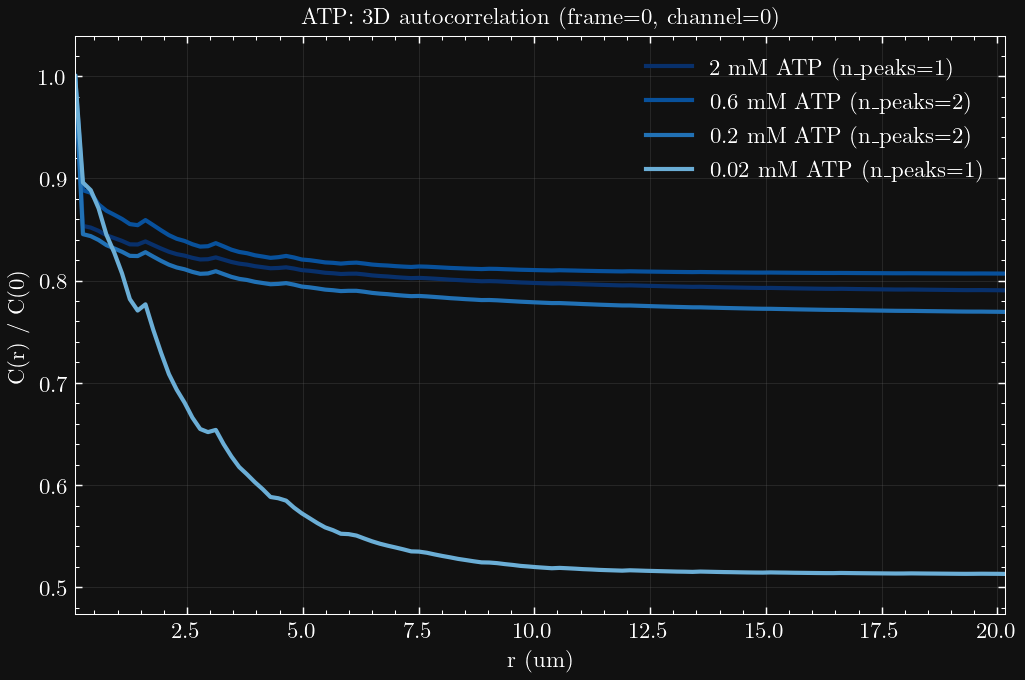

Saved: plots/data_comparison/ATP_autocorr3D_frame0_channel0_overlay_dark.pdf
Saved: plots/data_comparison/ATP_autocorr3D_frame0_channel0_overlay_white.pdf


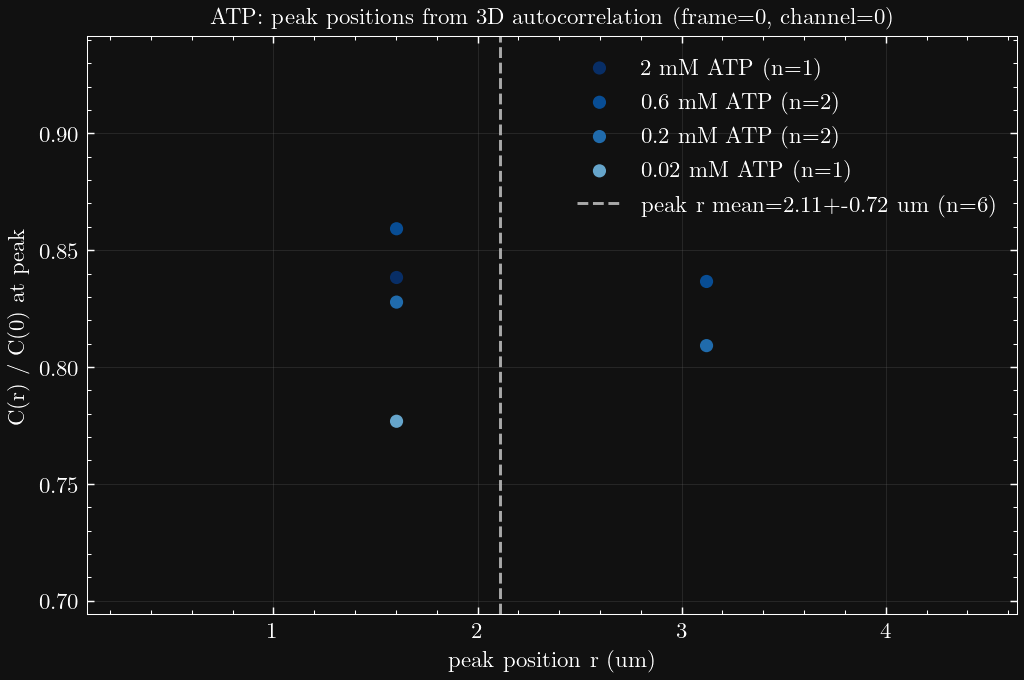

Saved: plots/data_comparison/ATP_autocorr3D_frame0_channel0_peaks_dark.pdf
Saved: plots/data_comparison/ATP_autocorr3D_frame0_channel0_peaks_white.pdf


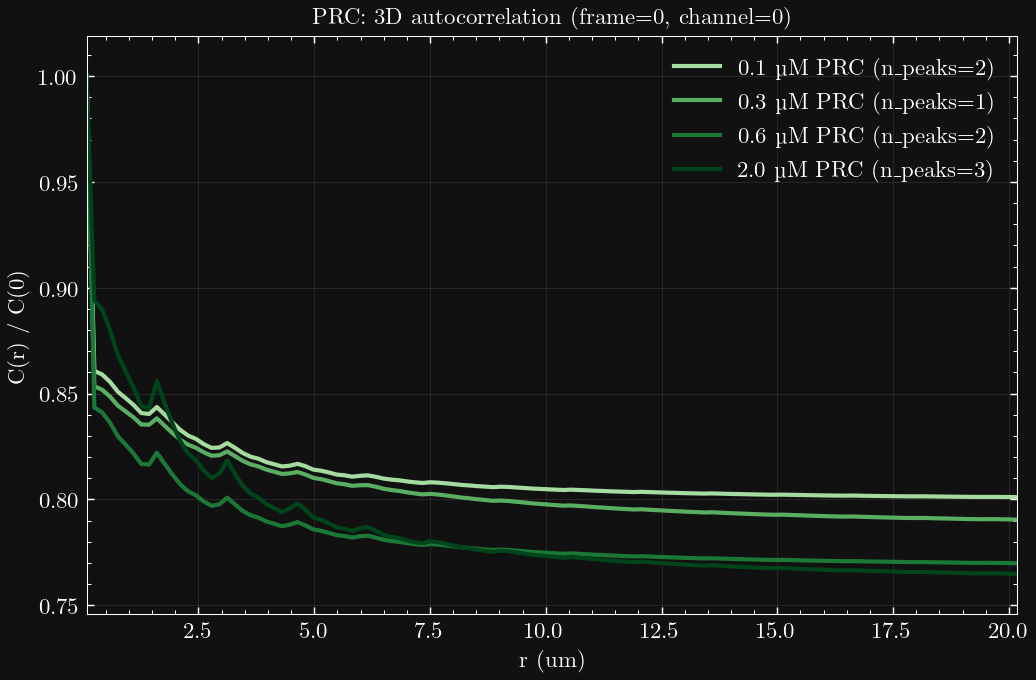

Saved: plots/data_comparison/prc_comparison/PRC_autocorr3D_frame0_channel0_overlay_dark.pdf
Saved: plots/data_comparison/prc_comparison/PRC_autocorr3D_frame0_channel0_overlay_white.pdf


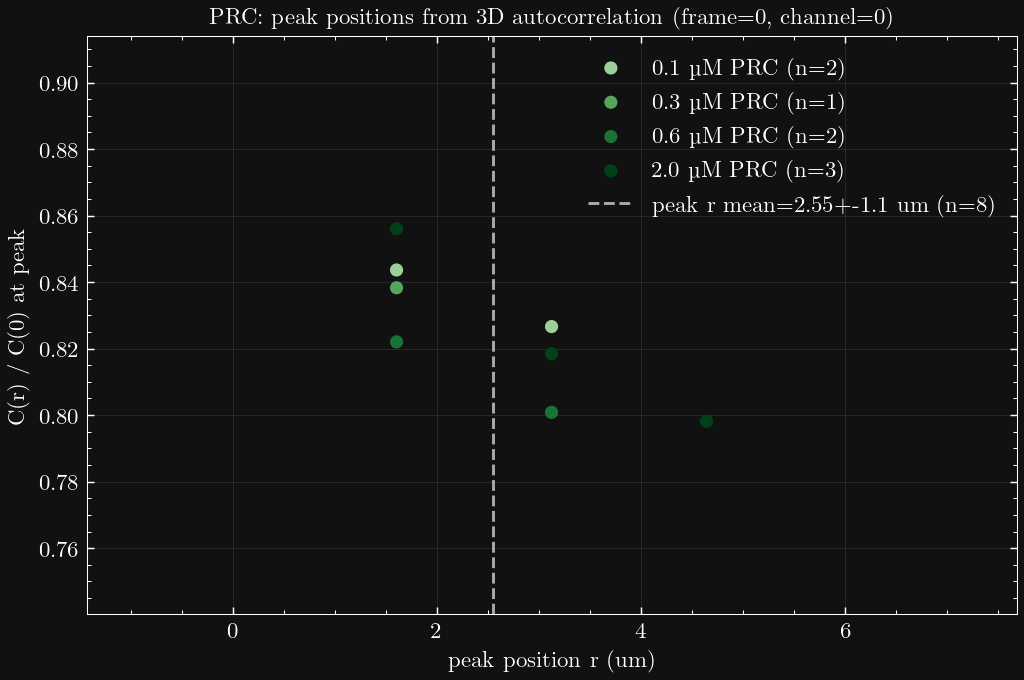

Saved: plots/data_comparison/prc_comparison/PRC_autocorr3D_frame0_channel0_peaks_dark.pdf
Saved: plots/data_comparison/prc_comparison/PRC_autocorr3D_frame0_channel0_peaks_white.pdf


In [12]:
# Plot autocorr overlays and peak-position comparisons (dark + white PDF versions)
def _apply_axes_theme(ax, dark=True):
    if dark:
        bg = '#111111'
        fg = 'white'
        grid_c = '#666666'
    else:
        bg = 'white'
        fg = 'black'
        grid_c = '#bbbbbb'

    ax.set_facecolor(bg)
    ax.figure.patch.set_facecolor(bg)
    ax.xaxis.label.set_color(fg)
    ax.yaxis.label.set_color(fg)
    ax.title.set_color(fg)
    ax.tick_params(colors=fg)
    for spine in ax.spines.values():
        spine.set_color(fg)
    ax.grid(True, alpha=0.25, color=grid_c)

def _save_figure_both_themes(make_fig_fn, out_stub):
    # dark (presentation)
    fig_d = make_fig_fn(dark=True)
    pdf_dark = f"{out_stub}_dark.pdf"
    fig_d.savefig(pdf_dark, dpi=150, bbox_inches='tight')
    plt.show()

    # white (paper)
    fig_w = make_fig_fn(dark=False)
    pdf_white = f"{out_stub}_white.pdf"
    fig_w.savefig(pdf_white, dpi=150, bbox_inches='tight')
    plt.close(fig_w)

    print(f"Saved: {pdf_dark}")
    print(f"Saved: {pdf_white}")

def make_overlay_plot(rows, title, dark=True):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    y_pool = []
    x_pool = []
    for rw in rows:
        r = np.asarray(rw['r_um'], dtype=float)
        c = np.asarray(rw['corr'], dtype=float)
        v = np.isfinite(r) & np.isfinite(c)
        if not np.any(v):
            continue
        rv, cv = r[v], c[v]
        x_pool.append(rv)
        y_pool.append(cv)
        lbl = f"{rw['label']} (n_peaks={int(rw['n_peaks'])})"
        ax.plot(rv, cv, lw=2.0, color=rw['color'], label=lbl)

    if x_pool:
        x_all = np.concatenate(x_pool)
        ax.set_xlim(float(np.nanmin(x_all)), float(np.nanmax(x_all)))
    if y_pool:
        y_all = np.concatenate(y_pool)
        ylo, yhi = float(np.nanmin(y_all)), float(np.nanmax(y_all))
        ypad = 0.08 * (yhi - ylo) if yhi > ylo else 0.1 * max(1.0, abs(yhi))
        ax.set_ylim(ylo - ypad, yhi + ypad)

    ax.set_xlabel('r (um)')
    ax.set_ylabel('C(r) / C(0)')
    ax.set_title(title)
    _apply_axes_theme(ax, dark=dark)
    ax.legend(loc='best', frameon=False)
    return fig

def make_peak_position_plot(rows, title, dark=True):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

    for i, rw in enumerate(rows):
        peaks_r = np.asarray(rw['peak_r_um'], dtype=float)
        peaks_c = np.asarray(rw['peak_corr'], dtype=float)
        if len(peaks_r) == 0:
            continue
        # sort peaks by prominence descending if available
        prom = np.asarray(rw['peak_prominence'], dtype=float)
        if len(prom) == len(peaks_r):
            order = np.argsort(-prom)
            peaks_r = peaks_r[order]
            peaks_c = peaks_c[order]

        ax.scatter(
            peaks_r,
            peaks_c,
            s=40,
            color=rw['color'],
            edgecolor='none',
            alpha=0.95,
            label=f"{rw['label']} (n={len(peaks_r)})",
        )

    # Add group-level mean +- std of peak positions for transparency.
    all_peaks = np.concatenate([np.asarray(rw['peak_r_um'], dtype=float) for rw in rows if len(rw['peak_r_um']) > 0]) if any(len(rw['peak_r_um']) > 0 for rw in rows) else np.array([])
    if len(all_peaks) > 0:
        mu = float(np.nanmean(all_peaks))
        sd = float(np.nanstd(all_peaks))
        ax.axvline(mu, color='#bbbbbb' if dark else '#444444', lw=1.4, ls='--', alpha=0.9, label=f'peak r mean={mu:.3g}+-{sd:.2g} um (n={len(all_peaks)})')

    ax.set_xlabel('peak position r (um)')
    ax.set_ylabel('C(r) / C(0) at peak')
    ax.set_title(title)
    _apply_axes_theme(ax, dark=dark)
    ax.legend(loc='best', frameon=False)
    return fig

if 'autocorr_compare_results' not in globals():
    raise RuntimeError('Run the autocorrelation compute cell first.')

atp_rows = autocorr_compare_results.get('atp', [])
prc_rows = autocorr_compare_results.get('prc', [])
frame_ac = int(autocorr_compare_results.get('frame', 0))
channel_ac = int(autocorr_compare_results.get('channel', 0))

if not atp_rows:
    print('No ATP autocorr rows to plot.')
else:
    atp_overlay_stub = os.path.join(out_dir, f'ATP_autocorr3D_frame{frame_ac}_channel{channel_ac}_overlay')
    _save_figure_both_themes(
        lambda dark: make_overlay_plot(
            atp_rows,
            title=f'ATP: 3D autocorrelation (frame={frame_ac}, channel={channel_ac})',
            dark=dark,
        ),
        atp_overlay_stub,
    )

    atp_peaks_stub = os.path.join(out_dir, f'ATP_autocorr3D_frame{frame_ac}_channel{channel_ac}_peaks')
    _save_figure_both_themes(
        lambda dark: make_peak_position_plot(
            atp_rows,
            title=f'ATP: peak positions from 3D autocorrelation (frame={frame_ac}, channel={channel_ac})',
            dark=dark,
        ),
        atp_peaks_stub,
    )

if not prc_rows:
    print('No PRC autocorr rows to plot.')
else:
    prc_overlay_stub = os.path.join(out_dir_prc, f'PRC_autocorr3D_frame{frame_ac}_channel{channel_ac}_overlay')
    _save_figure_both_themes(
        lambda dark: make_overlay_plot(
            prc_rows,
            title=f'PRC: 3D autocorrelation (frame={frame_ac}, channel={channel_ac})',
            dark=dark,
        ),
        prc_overlay_stub,
    )

    prc_peaks_stub = os.path.join(out_dir_prc, f'PRC_autocorr3D_frame{frame_ac}_channel{channel_ac}_peaks')
    _save_figure_both_themes(
        lambda dark: make_peak_position_plot(
            prc_rows,
            title=f'PRC: peak positions from 3D autocorrelation (frame={frame_ac}, channel={channel_ac})',
            dark=dark,
        ),
        prc_peaks_stub,
    )

Reference dataset: AMF_088_002__C640_C470 from /Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260225
Reference frame shape (Z,Y,X): (27, 2818, 2829)
Noise stats: mean=32.58, std=17.3


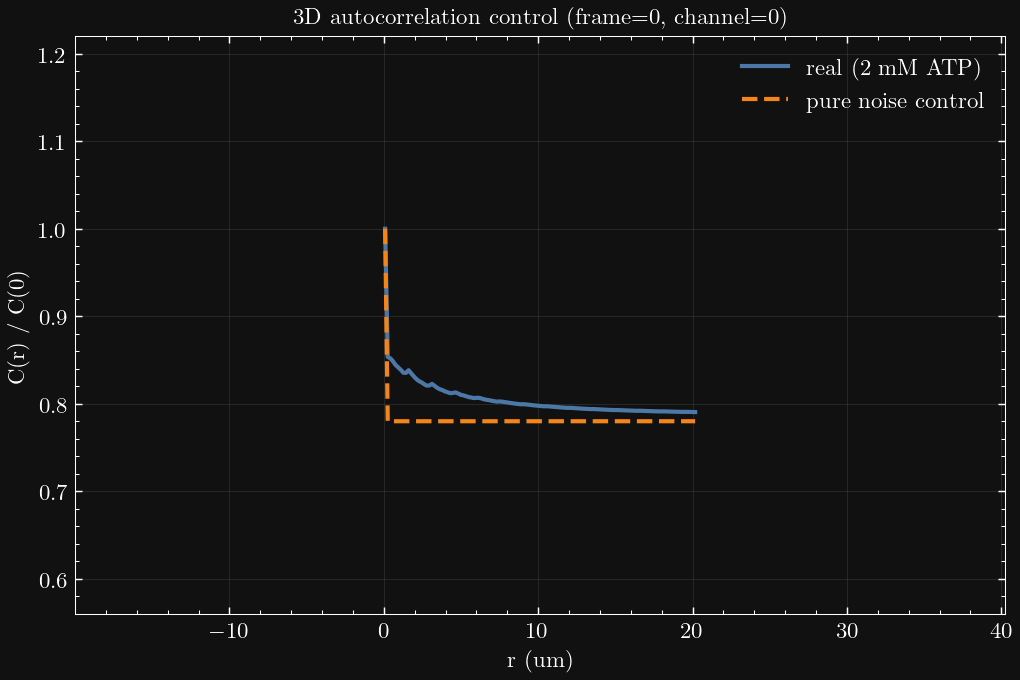

Saved: plots/data_comparison/noise_control_autocorr3D_frame0_channel0_dark.pdf
Saved: plots/data_comparison/noise_control_autocorr3D_frame0_channel0_white.pdf
Stored results in noise_control_results


In [13]:
# Control: pure-noise 3D autocorrelation using the same frame dimensions as a real dataset
import importlib
import tomsUtilities
importlib.reload(tomsUtilities)
from tomsUtilities import mass_mass_corr_per_frame

if 'autocorr_compare_results' not in globals():
    raise RuntimeError('Run the frame-0 autocorrelation compute cell first.')

ref_rows = autocorr_compare_results.get('atp', []) + autocorr_compare_results.get('prc', [])
if not ref_rows:
    raise RuntimeError('No reference datasets available for control dimensions.')

ref = ref_rows[0]
ref_id = ref.get('dataset_id_resolved', ref.get('dataset_id'))

base_candidates = []
for b in [globals().get('base_dir', None), '/Volumes/TOM_DATA', globals().get('base_dir_prc', None)]:
    if isinstance(b, str) and len(b) > 0:
        base_candidates.append(b)

if not base_candidates:
    raise RuntimeError('No base directory candidates available in notebook globals.')

# Resolve dataset location.
ref_base = None
for b in base_candidates:
    if os.path.exists(os.path.join(b, ref_id)):
        ref_base = b
        break
if ref_base is None:
    raise RuntimeError(f'Could not locate reference dataset {ref_id} in candidate base directories.')

images_ref, _ = open_raw_lazy(ref_id, base_dir=ref_base)
px_xy_ref, _, px_z_ref, _ = read_zarr_calibration(ref_id, base_dir=ref_base)

frame_ctrl = int(globals().get('frame_ac', 0))
channel_ctrl = int(globals().get('channel_ac', 0))
nbins_ctrl = int(globals().get('nbins_ac', 120))

if images_ref.ndim != 5:
    raise RuntimeError(f'Reference dataset is not TCZYX; shape={images_ref.shape}')
if frame_ctrl >= int(images_ref.shape[0]) or channel_ctrl >= int(images_ref.shape[1]):
    raise RuntimeError(f'Frame/channel out of bounds for shape {images_ref.shape}')

vol_real = np.asarray(images_ref[frame_ctrl, channel_ctrl].compute(), dtype=np.float32)
if vol_real.ndim != 3:
    raise RuntimeError(f'Reference frame is not 3D; shape={vol_real.shape}')

mu = float(np.nanmean(vol_real))
sd = float(np.nanstd(vol_real))
if not np.isfinite(sd) or sd <= 0:
    sd = 1.0

rng = np.random.default_rng(42)
vol_noise = rng.normal(loc=mu, scale=sd, size=vol_real.shape).astype(np.float32)

pz = float(px_z_ref) if (px_z_ref is not None and float(px_z_ref) > 0) else float(px_xy_ref)

r_um_ctrl, corr_real_ctrl = mass_mass_corr_per_frame(
    imgs=vol_real[np.newaxis, ...],
    px_per_micron=float(px_xy_ref),
    px_per_micron_z=float(pz),
    nbins=nbins_ctrl,
    subtract_mean=False,
    normalize='c0',
)
r_um_noise, corr_noise = mass_mass_corr_per_frame(
    imgs=vol_noise[np.newaxis, ...],
    px_per_micron=float(px_xy_ref),
    px_per_micron_z=float(pz),
    nbins=nbins_ctrl,
    subtract_mean=False,
    normalize='c0',
)

r_real = np.asarray(r_um_ctrl, dtype=float)
c_real = np.asarray(corr_real_ctrl[0], dtype=float)
r_noise = np.asarray(r_um_noise, dtype=float)
c_noise = np.asarray(corr_noise[0], dtype=float)

m_real = np.isfinite(r_real) & np.isfinite(c_real)
m_noise = np.isfinite(r_noise) & np.isfinite(c_noise)
r_real, c_real = r_real[m_real], c_real[m_real]
r_noise, c_noise = r_noise[m_noise], c_noise[m_noise]

print(f'Reference dataset: {ref_id} from {ref_base}')
print(f'Reference frame shape (Z,Y,X): {vol_real.shape}')
print(f'Noise stats: mean={float(np.mean(vol_noise)):.4g}, std={float(np.std(vol_noise)):.4g}')

if '_apply_axes_theme' not in globals():
    def _apply_axes_theme(ax, dark=True):
        if dark:
            bg = '#111111'
            fg = 'white'
            grid_c = '#666666'
        else:
            bg = 'white'
            fg = 'black'
            grid_c = '#bbbbbb'
        ax.set_facecolor(bg)
        ax.figure.patch.set_facecolor(bg)
        ax.xaxis.label.set_color(fg)
        ax.yaxis.label.set_color(fg)
        ax.title.set_color(fg)
        ax.tick_params(colors=fg)
        for spine in ax.spines.values():
            spine.set_color(fg)
        ax.grid(True, alpha=0.25, color=grid_c)

if '_save_figure_both_themes' not in globals():
    def _save_figure_both_themes(make_fig_fn, out_stub):
        fig_d = make_fig_fn(dark=True)
        pdf_dark = f'{out_stub}_dark.pdf'
        fig_d.savefig(pdf_dark, dpi=150, bbox_inches='tight')
        plt.show()

        fig_w = make_fig_fn(dark=False)
        pdf_white = f'{out_stub}_white.pdf'
        fig_w.savefig(pdf_white, dpi=150, bbox_inches='tight')
        plt.close(fig_w)

        print(f'Saved: {pdf_dark}')
        print(f'Saved: {pdf_white}')

out_dir_ctrl = globals().get('out_dir', os.path.join('plots', 'data_comparison'))
os.makedirs(out_dir_ctrl, exist_ok=True)
out_stub_ctrl = os.path.join(out_dir_ctrl, f'noise_control_autocorr3D_frame{frame_ctrl}_channel{channel_ctrl}')

def _make_noise_control_plot(dark=True):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    ax.plot(r_real, c_real, lw=2.0, color='#4c78a8', label=f'real ({ref.get("label", ref_id)})')
    ax.plot(r_noise, c_noise, lw=2.0, color='#f58518', ls='--', label='pure noise control')
    ax.set_xlabel('r (um)')
    ax.set_ylabel('C(r) / C(0)')
    ax.set_title(f'3D autocorrelation control (frame={frame_ctrl}, channel={channel_ctrl})')
    _apply_axes_theme(ax, dark=dark)
    ax.legend(loc='best', frameon=False)
    return fig

_save_figure_both_themes(_make_noise_control_plot, out_stub_ctrl)

noise_control_results = {
    'reference_dataset_id': ref_id,
    'reference_base_dir': ref_base,
    'frame': frame_ctrl,
    'channel': channel_ctrl,
    'r_um_real': r_real,
    'corr_real': c_real,
    'r_um_noise': r_noise,
    'corr_noise': c_noise,
    'noise_seed': 42,
}
print('Stored results in noise_control_results')

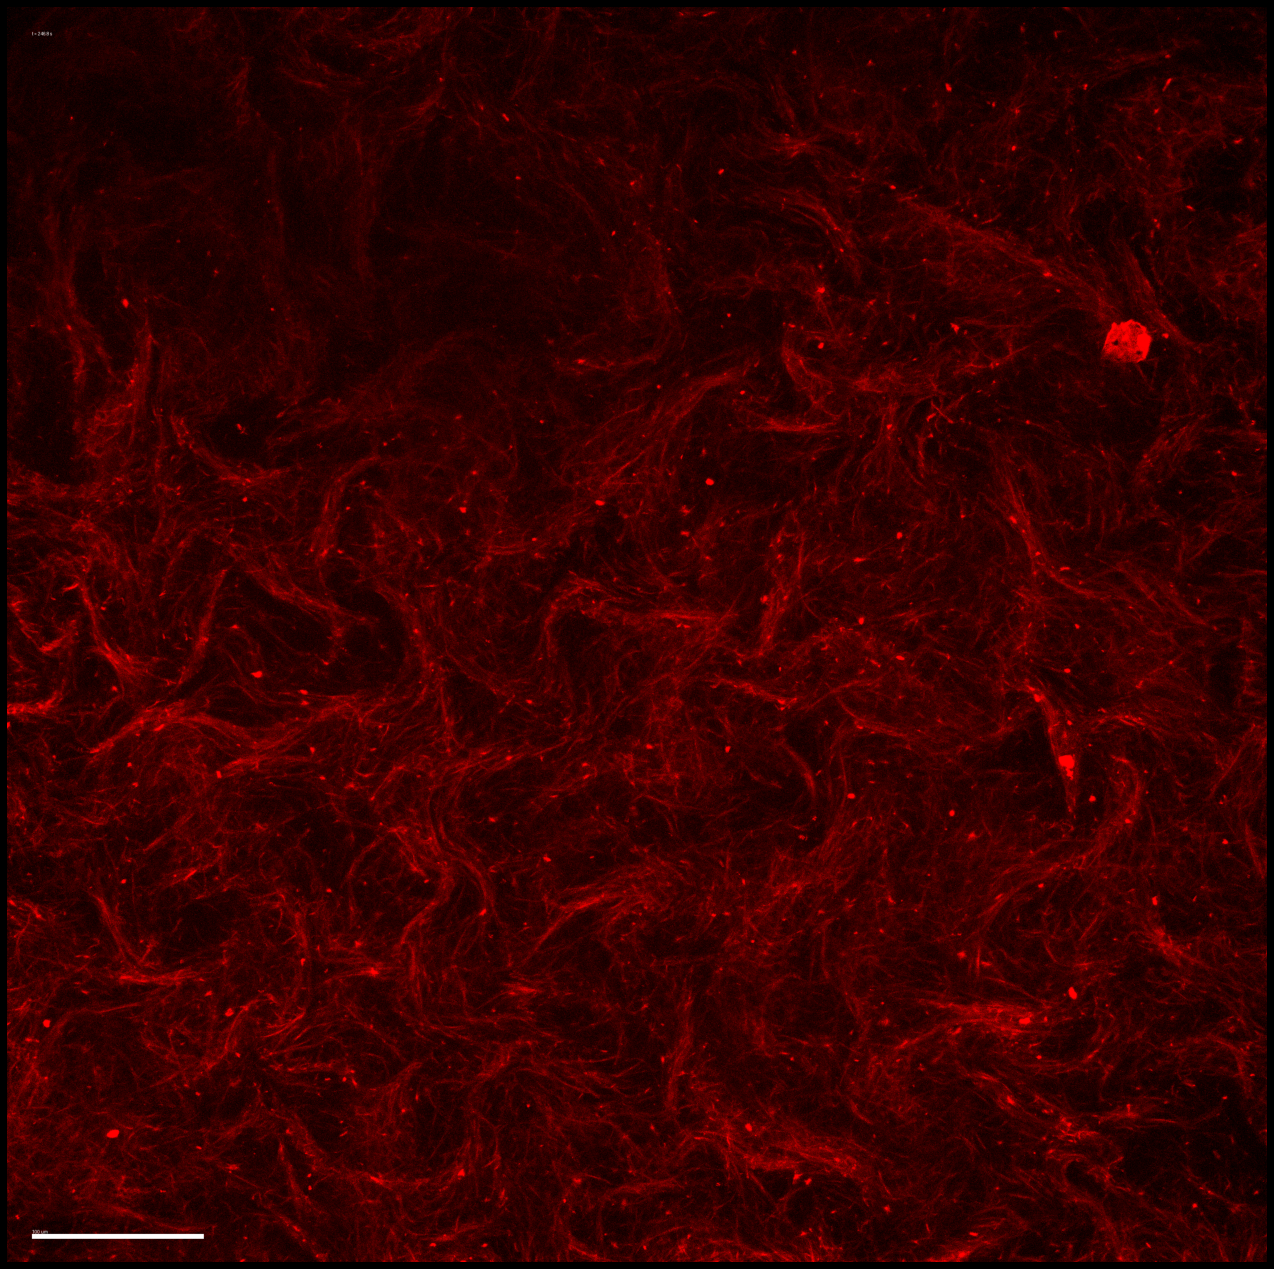

Preview condition: ATP | 2 mM ATP | AMF_088_002__C640_C470
Preview frame: 10, displayed time=246.76 s
Reference data source: /Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260225
If this look is correct, run the next cell to export all movies.


In [18]:
# Movie export prep: red z-projection frames with scale bar + time overlay
import re
import cv2
from PIL import Image, ImageDraw, ImageFont

movie_export_fps = 10
movie_channel = 0
scale_bar_um = 100.0
movie_out_dir = os.path.join(out_dir, 'movies_mt_zproj')
os.makedirs(movie_out_dir, exist_ok=True)

conditions_all = [
    ('ATP', ds_id, ds_label, [base_dir, '/Volumes/TOM_DATA'])
    for ds_id, ds_label, _ in datasets_cmp
] + [
    ('PRC', ds_id, ds_label, [base_dir_prc, '/Volumes/TOM_DATA', base_dir])
    for ds_id, ds_label, _ in datasets_prc
]

def _resolve_base_dir(ds_id, base_candidates):
    for b in base_candidates:
        if isinstance(b, str) and os.path.exists(os.path.join(b, ds_id)):
            return b
    return None

def _safe_name(txt):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(txt)).strip('_')

def _red_lut_rgb(img2d, q_low=1.0, q_high=99.8):
    arr = np.asarray(img2d, dtype=np.float32)
    valid = np.isfinite(arr)
    if not np.any(valid):
        arr = np.zeros_like(arr, dtype=np.float32)
    else:
        lo = float(np.nanpercentile(arr[valid], q_low))
        hi = float(np.nanpercentile(arr[valid], q_high))
        if not np.isfinite(lo):
            lo = 0.0
        if not np.isfinite(hi) or hi <= lo:
            hi = lo + 1.0
        arr = np.clip((arr - lo) / (hi - lo), 0.0, 1.0)

    rgb = np.zeros((*arr.shape, 3), dtype=np.uint8)
    rgb[..., 0] = np.round(255.0 * arr).astype(np.uint8)
    return rgb

def _draw_overlays(rgb, px_per_micron_xy, time_s, scale_bar_um=100.0):
    img = Image.fromarray(rgb)
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()

    h, w = rgb.shape[:2]
    pad = max(8, int(round(0.02 * min(h, w))))
    bar_px = int(round(scale_bar_um * float(px_per_micron_xy))) if (px_per_micron_xy is not None and float(px_per_micron_xy) > 0) else 0
    bar_px = max(1, min(bar_px, int(0.45 * w)))

    x0 = pad
    y0 = h - pad - 2
    x1 = x0 + bar_px
    y1 = y0

    draw.line([(x0, y0), (x1, y1)], fill=(255, 255, 255), width=max(2, int(round(0.004 * h))))
    draw.text((x0, y0 - 16), f'{scale_bar_um:.0f} um', fill=(255, 255, 255), font=font)
    draw.text((pad, pad), f't = {time_s:.1f} s', fill=(255, 255, 255), font=font)

    return np.asarray(img)

def load_condition_stack(ds_id, base_candidates):
    base_found = _resolve_base_dir(ds_id, base_candidates)
    if base_found is None:
        raise FileNotFoundError(f'Could not find dataset {ds_id} in base candidates: {base_candidates}')
    images, _ = open_raw_lazy(ds_id, base_dir=base_found)
    px_xy, _, _, fps_acq = read_zarr_calibration(ds_id, base_dir=base_found)
    return images, float(px_xy), (float(fps_acq) if fps_acq is not None else np.nan), base_found

def make_projected_frame_rgb(images, frame_idx, channel_idx, px_xy, fps_acq):
    vol = np.asarray(images[int(frame_idx), int(channel_idx)].compute(), dtype=np.float32)
    if vol.ndim != 3:
        raise RuntimeError(f'Expected 3D stack at frame/channel, got shape {vol.shape}')
    mip = np.nanmax(vol, axis=0)
    rgb = _red_lut_rgb(mip)
    if np.isfinite(fps_acq) and fps_acq > 0:
        t_s = float(frame_idx) / float(fps_acq)
    else:
        t_s = float(frame_idx) / float(movie_export_fps)
    rgb = _draw_overlays(rgb, px_per_micron_xy=px_xy, time_s=t_s, scale_bar_um=scale_bar_um)
    return rgb, t_s

def export_condition_movie(condition_name, ds_id, ds_label, base_candidates, channel_idx=0, fps_out=10):
    images, px_xy, fps_acq, base_found = load_condition_stack(ds_id, base_candidates)
    n_frames = int(images.shape[0])

    base_name = f"{condition_name}_{_safe_name(ds_label)}_{_safe_name(ds_id)}_zproj_red"
    out_mp4 = os.path.join(movie_out_dir, f'{base_name}.mp4')

    first_rgb, _ = make_projected_frame_rgb(images, 0, channel_idx, px_xy, fps_acq)
    h, w = first_rgb.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(out_mp4, fourcc, float(fps_out), (w, h))
    if not video.isOpened():
        raise RuntimeError('Could not open cv2.VideoWriter for MP4 export.')

    try:
        for fi in range(n_frames):
            frame_rgb, _ = make_projected_frame_rgb(images, fi, channel_idx, px_xy, fps_acq)
            frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
            video.write(frame_bgr)
    finally:
        video.release()

    print(f'Saved movie: {out_mp4}')
    print(f'  frames={n_frames}, output_fps={fps_out}, source_base={base_found}')
    return out_mp4

# Preview one frame before exporting all movies.
preview_condition = conditions_all[0]
preview_cond_name, preview_ds_id, preview_ds_label, preview_bases = preview_condition
preview_images, preview_px_xy, preview_fps_acq, preview_base = load_condition_stack(preview_ds_id, preview_bases)
preview_frame_idx = min(10, int(preview_images.shape[0]) - 1)
preview_rgb, preview_time_s = make_projected_frame_rgb(
    preview_images,
    frame_idx=preview_frame_idx,
    channel_idx=movie_channel,
    px_xy=preview_px_xy,
    fps_acq=preview_fps_acq,
)

h, w = preview_rgb.shape[:2]
fig_w = 9.0
fig_h = fig_w * (h / w)
plt.figure(figsize=(fig_w, fig_h), dpi=140)
plt.imshow(preview_rgb)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

print(f'Preview condition: {preview_cond_name} | {preview_ds_label} | {preview_ds_id}')
print(f'Preview frame: {preview_frame_idx}, displayed time={preview_time_s:.2f} s')
print(f'Reference data source: {preview_base}')
print('If this look is correct, run the next cell to export all movies.')

In [19]:
# Export all condition movies after preview approval
run_export_all_movies = True

if not run_export_all_movies:
    print('Preview gate active. Set run_export_all_movies = True in this cell to export all condition movies.')
else:
    saved_movie_paths = []
    for cond_name, ds_id, ds_label, base_candidates in conditions_all:
        try:
            out_path = export_condition_movie(
                condition_name=cond_name,
                ds_id=ds_id,
                ds_label=ds_label,
                base_candidates=base_candidates,
                channel_idx=movie_channel,
                fps_out=movie_export_fps,
            )
            saved_movie_paths.append(out_path)
        except Exception as exc:
            print(f'Skipping {cond_name} | {ds_label} | {ds_id}: {exc}')

    print('Done exporting condition movies.')
    for p in saved_movie_paths:
        print(p)

Saved movie: plots/data_comparison/movies_mt_zproj/ATP_2_mM_ATP_AMF_088_002__C640_C470_zproj_red.mp4
  frames=222, output_fps=10, source_base=/Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260225
Saved movie: plots/data_comparison/movies_mt_zproj/ATP_0.6_mM_ATP_AMF_101_002__C640_C470_zproj_red.mp4
  frames=222, output_fps=10, source_base=/Volumes/TOM_DATA
Skipping ATP | 0.2 mM ATP | AMF_089_003__C640_C470: error during blosc decompression: -1
Saved movie: plots/data_comparison/movies_mt_zproj/ATP_0.02_mM_ATP_AMF_090_003__C640_C470_zproj_red.mp4
  frames=222, output_fps=10, source_base=/Volumes/dataserver_files/Group_Bausch/Tom_Dataserver/20260225
Saved movie: plots/data_comparison/movies_mt_zproj/PRC_0.1_M_PRC_AMF_092_002__C640_C470_zproj_red.mp4
  frames=222, output_fps=10, source_base=/Volumes/TOM_DATA
Saved movie: plots/data_comparison/movies_mt_zproj/PRC_0.3_M_PRC_AMF_088_002__C640_C470_zproj_red.mp4
  frames=222, output_fps=10, source_base=/Volumes/TOM_DATA
Saved movie: p